In [1]:
import json

with open("Escia Full 2026-03-05-21-24.json", "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['info', 'settings', 'mapCoordinates', 'pack', 'grid', 'biomesData', 'notes', 'nameBases'])


In [2]:
print(data['pack'].keys())

dict_keys(['cells', 'vertices', 'features', 'cultures', 'burgs', 'states', 'provinces', 'religions', 'rivers', 'markers', 'routes', 'zones'])


In [3]:
pack = data['pack']
cells = pack['cells']
print(cells[0])
print(len(cells))

{'i': 0, 'v': [7891, 8566, 8785, 8978, 9102, 8457, 8374, 8147], 'c': [3, 2, 7, 6, 4], 'p': [1140.79, 51.9], 'g': 635, 'h': 16, 'area': 1500, 'f': 1, 't': -3, 'haven': 0, 'harbor': 0, 'fl': 0, 'r': 0, 'conf': 0, 'biome': 0, 's': 0, 'pop': 0, 'culture': 0, 'burg': 0, 'state': 0, 'religion': 0, 'province': 0}
5538


In [4]:
print('biomes')
print(data['biomesData'])

for key in pack.keys():
    print(key)
    for entry in pack[key][:2]:
        print(entry)

biomes
{'i': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'name': ['Marine', 'Hot desert', 'Cold desert', 'Savanna', 'Grassland', 'Tropical seasonal forest', 'Temperate deciduous forest', 'Tropical rainforest', 'Temperate rainforest', 'Taiga', 'Tundra', 'Glacier', 'Wetland'], 'color': ['#466eab', '#fbe79f', '#b5b887', '#d2d082', '#c8d68f', '#b6d95d', '#29bc56', '#7dcb35', '#409c43', '#4b6b32', '#96784b', '#d5e7eb', '#0b9131'], 'biomesMatrix': [{'0': 1, '1': 1, '2': 1, '3': 1, '4': 1, '5': 1, '6': 1, '7': 1, '8': 2, '9': 2, '10': 2, '11': 2, '12': 2, '13': 2, '14': 2, '15': 2, '16': 2, '17': 2, '18': 2, '19': 2, '20': 2, '21': 2, '22': 2, '23': 2, '24': 2, '25': 10}, {'0': 3, '1': 3, '2': 3, '3': 4, '4': 4, '5': 4, '6': 4, '7': 4, '8': 4, '9': 4, '10': 4, '11': 4, '12': 4, '13': 4, '14': 4, '15': 4, '16': 4, '17': 4, '18': 4, '19': 9, '20': 9, '21': 9, '22': 9, '23': 10, '24': 10, '25': 10}, {'0': 5, '1': 6, '2': 6, '3': 6, '4': 6, '5': 6, '6': 6, '7': 6, '8': 6, '9': 6, '10': 6, '11': 6

In [5]:
biomes_Data = data['biomesData']
vertices = data['pack']['vertices']
vertex_lookup = {v['i']:v['p'] for v in vertices if isinstance(v, dict) }

def make_lookup(data, key='i', value = 'name'):
    if isinstance(data, dict):
        return {k: v for k, v in zip(data[key], data[value])}
    else:
        return {e[key]: e[value] for e in data if isinstance(e, dict)}
    
lookup_table = {
    "biome":    make_lookup(biomes_Data)
}


lookups = {
    "biome":    make_lookup(biomes_Data),
    "state":    make_lookup(pack["states"]),
    "culture":  make_lookup(pack["cultures"]),
    "religion": make_lookup(pack["religions"]),
    "province": make_lookup(pack["provinces"]),
}


for name, lookup in lookups.items():
    print(f"{name}: {lookup}\n")





biome: {0: 'Marine', 1: 'Hot desert', 2: 'Cold desert', 3: 'Savanna', 4: 'Grassland', 5: 'Tropical seasonal forest', 6: 'Temperate deciduous forest', 7: 'Tropical rainforest', 8: 'Temperate rainforest', 9: 'Taiga', 10: 'Tundra', 11: 'Glacier', 12: 'Wetland'}

state: {0: 'Neutrals', 1: 'Zhen Guo', 2: 'Maia', 3: 'Songnam', 4: 'Gia', 5: 'Laicheung', 6: 'Chia', 7: 'Zarmaqersia', 8: 'Datienia', 9: 'Bulagia', 10: 'Xiansu', 11: 'Hong', 12: 'Cheonjeop', 13: 'Guraga', 14: 'Ybarjan', 15: 'Heungia', 16: 'Yeonguk', 17: 'Uiheunguk', 18: 'Atanz', 19: 'Xiyuande'}

culture: {0: 'Wildlands', 1: 'Turchian', 2: 'Maui', 3: 'Tehrani', 4: 'Hantzu', 5: 'Eurabic', 6: 'Ulus', 7: 'Vietic', 8: 'Guantzu', 9: 'Yamoto', 10: 'Koryo', 11: 'Efratic', 12: 'Carnatic'}

religion: {0: 'No religion', 1: 'Turchian Beliefs', 2: 'Maui Beliefs', 3: 'Old Tehrani Shamanism', 4: 'Hantzu Beliefs', 5: 'Eurabic Beliefs', 6: 'Ulus Spirits', 7: 'Vietic Beliefs', 8: 'Guantzu Shamanism', 9: 'Yamoto Spirits', 10: 'Koryo Gods', 11: 'Efrat

In [6]:
import networkx as nx

UNINHABITABLE_BIOMES = {i for i, h in zip(biomes_Data["i"], biomes_Data["habitability"]) if h == 0}

def is_land_cell(cell):
    return (
        cell['biome'] not in UNINHABITABLE_BIOMES and
        cell['state'] != 0 and
        cell['culture'] != 0
    )

land_cells = [c for c in cells if is_land_cell(c)]
cell_lookup = {c['i']:c for c in land_cells}
land_ids = set(cell_lookup.keys())

print(f'Total cells: {len(cells)}, Land cells: {len(land_cells)}')
print(f'Land/Water Ratio = {(len(land_cells)/len(cells)*100):2f} %')

WEIGHTS = {"biome": 1.0, "state": 1.0, "culture": 1.0, "religion": 1.0}


Total cells: 5538, Land cells: 3806
Land/Water Ratio = 68.725172 %


In [7]:
def similarity(a, b):
    score = sum(w for attr, w in WEIGHTS.items() if a[attr] == b[attr])
    return score/sum(WEIGHTS.values())

G = nx.Graph()

for cell in land_cells:
    G.add_node(cell['i'])
    for neighbor_id in cell['c']:
        if neighbor_id in land_ids and not G.has_edge(cell['i'], neighbor_id):
            w = similarity(cell, cell_lookup[neighbor_id])
            G.add_edge(cell["i"], neighbor_id, weight=w)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 3806, Edges: 10299


In [8]:
import community as louvain

# for res in [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 5.0, 10.0]:
#     p = louvain.best_partition(G, weight="weight", resolution=res)
#     n = len(set(p.values()))
#     print(f"resolution={res}: {n} regions")

partition = louvain.best_partition(G,resolution=1)
num_regions = len(set(partition.values()))
print(f'Number of regions partitioned; {num_regions}')

from collections import Counter
region_sizes = Counter(partition.values())
print(f"\nRegion size distribution:")
print(f"  Largest region: {max(region_sizes.values())} cells")
print(f"  Smallest region: {min(region_sizes.values())} cells")
print(f"  Average region size: {sum(region_sizes.values()) / len(region_sizes):.1f} cells")


Number of regions partitioned; 34

Region size distribution:
  Largest region: 225 cells
  Smallest region: 1 cells
  Average region size: 111.9 cells


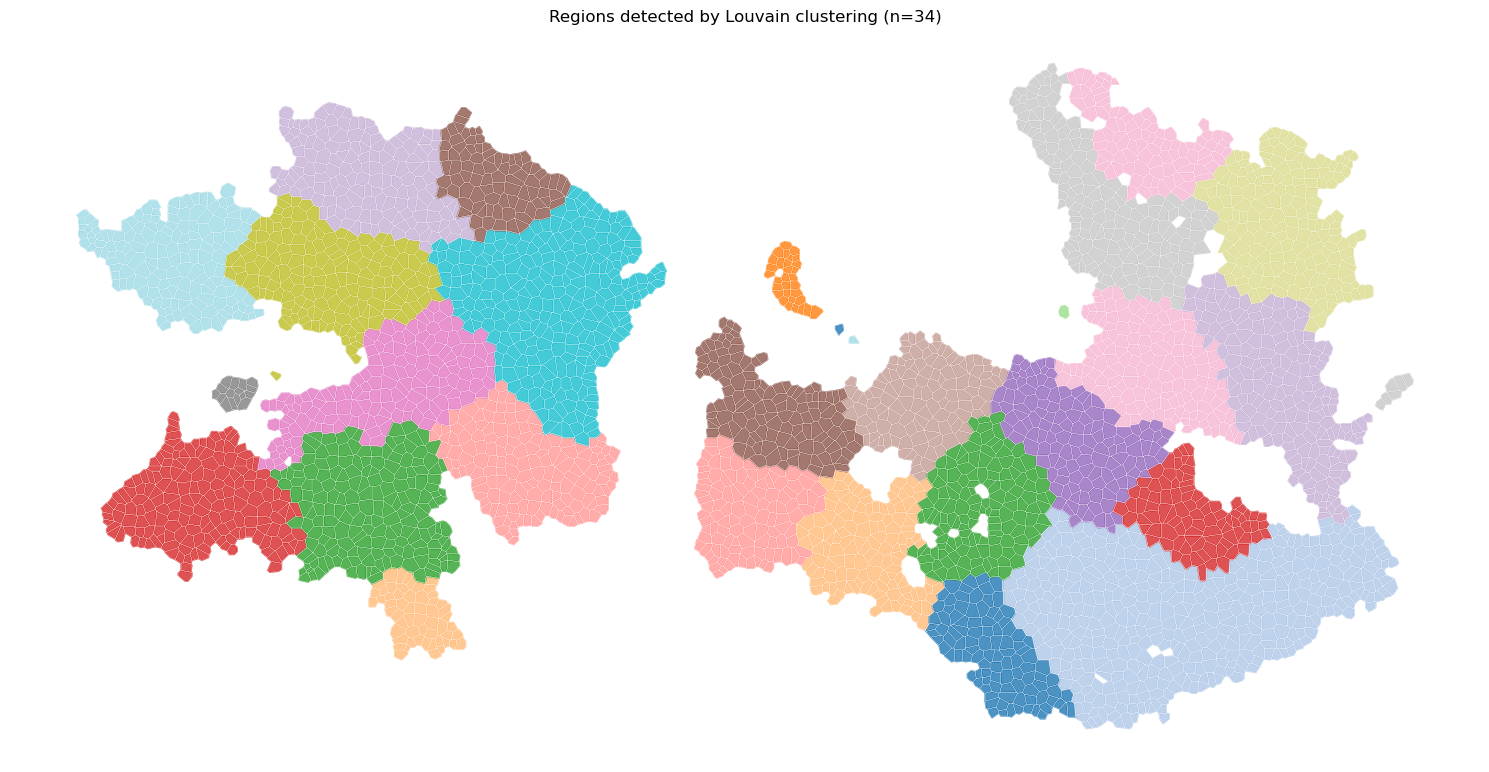

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.colormaps.get_cmap("tab20").resampled(num_regions)

region_colors = {region_id:cmap(i) for i, region_id in enumerate(set(partition.values()))}

fig, ax = plt.subplots(figsize=(15,10))

# vertices
# {'i': 0, 'p': [764, 425], 'v': [10, 7, 1], 'c': [2296, 2191, 2190]}
# {'i': 1, 'p': [764, 426], 'v': [3, 6, 0], 'c': [2190, 2295, 2296]}

for cell in land_cells:
    cell_id = cell['i']
    region_id = partition[cell_id]
    color = region_colors[region_id]

    verts = [vertex_lookup[v] for v in cell['v']]
    xs = [v[0] for v in verts]
    ys = [v[1] for v in verts]

    ax.fill(xs, ys, color=color, alpha= 0.8)
    ax.plot(xs + [xs[0]], ys + [ys[0]],  color='white', linewidth = 0.2)

ax.set_aspect("equal")
ax.set_title(f"Regions detected by Louvain clustering (n={num_regions})")
ax.axis("off")
plt.tight_layout()
plt.show()